In [ ]:
#Requirements
#pip3 install requests
#pip3 install bs4

## Web with Selinium and BeautifulSoup

### using the bing chatbot

In [21]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import random

# Start Chrome browser
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

# Open Bing Chat
driver.get("https://bing.com/chat")
time.sleep(5)  # wait for page to load


## Locating the input box and generating the reponse

In [24]:
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

# Locate the chat input box (inspect element in Bing Chat page for correct selector)
chat_input = driver.find_element(By.ID, "userInput")
chat_input.send_keys("Hello what can you do!")
chat_input.send_keys(Keys.RETURN)  # press Enter

# wait for Bing to generate a response
time.sleep(5)


In [25]:
from bs4 import BeautifulSoup

# Get page source after query is processed
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

# Adjust the class/id after inspecting Bing Chat DOM
response_divs = soup.find_all("div", class_="group/ai-message-item space-y-3 break-words")  

for idx, div in enumerate(response_divs):
    print(f"Response {idx+1}:")
    print(div.get_text(strip=True))
    print("----------")


Response 1:
Hey there! 👋 Great to see you pop in. Whether you're here to brainstorm, unwind, learn something new, or just chat—I’m all ears (well, metaphorically). What’s on your mind tonight?Edit in a page
----------
Response 2:
Hey hey! 😄 I'm Copilot, your endlessly curious, always-ready-to-help AI companion. Here's a taste of what I can do:💡 Spark IdeasNeed a business name, story plot, or gift idea? I’m your brainstorming buddy.Want to start a side hustle or pick up a new hobby? I’ll help you explore options.✍️ Write & CreateI can help you write essays, emails, poems, speeches, or even rap lyrics.Want to craft a compelling resume or LinkedIn profile? I’ve got you covered.📚 Learn & ExplainI break down complex topics—science, history, tech, you name it.I can quiz you, tutor you, or help prep for exams.🎨 Get VisualI can generate images based on your ideas—fantasy scenes, logos, characters, and more.You can also upload an image and ask me questions about it.🔍 Search & DiscoverI find the

## Generating the CSV file

In [28]:
import csv

# Collect responses
responses = []
for idx, div in enumerate(response_divs):
    text = div.get_text(strip=True)
    responses.append({"id": idx+1, "response": text})

# Save to CSV
with open("responses.csv", "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=["id", "response"])
    writer.writeheader()
    writer.writerows(responses)

print("Responses saved to responses.csv")


Responses saved to responses.csv


In [29]:
import csv
from datetime import datetime

def save_response(query, responses, filename="responses.csv"):
    with open(filename, "a", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        # write header if file is empty
        if csvfile.tell() == 0:
            writer.writerow(["timestamp", "query", "response"])
        
        for res in responses:
            writer.writerow([datetime.now().isoformat(), query, res])


In [30]:
query = "Hello what can you do!"
responses = [div.get_text(strip=True) for div in response_divs]
save_response(query, responses)


In [ ]:
import time, random
time.sleep(random.uniform(3, 8))  # wait between 3–8s



### Reading the CSV file using Pandas

In [35]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("responses.csv", on_bad_lines='skip')

print(df.head())  # Preview first 5 rows


   id                                           response
0   1  Hey there! 👋 Great to see you pop in. Whether ...
1   2  Hey hey! 😄 I'm Copilot, your endlessly curious...


In [36]:
# Number of responses
print("Total responses:", len(df))

# Average response length
df['response_length'] = df['response'].str.len()
print("Average response length:", df['response_length'].mean())

# Longest and shortest response
print("Longest response:", df.loc[df['response_length'].idxmax(), 'response'])
print("Shortest response:", df.loc[df['response_length'].idxmin(), 'response'])


Total responses: 2
Average response length: 667.0
Longest response: Hey hey! 😄 I'm Copilot, your endlessly curious, always-ready-to-help AI companion. Here's a taste of what I can do:💡 Spark IdeasNeed a business name, story plot, or gift idea? I’m your brainstorming buddy.Want to start a side hustle or pick up a new hobby? I’ll help you explore options.✍️ Write & CreateI can help you write essays, emails, poems, speeches, or even rap lyrics.Want to craft a compelling resume or LinkedIn profile? I’ve got you covered.📚 Learn & ExplainI break down complex topics—science, history, tech, you name it.I can quiz you, tutor you, or help prep for exams.🎨 Get VisualI can generate images based on your ideas—fantasy scenes, logos, characters, and more.You can also upload an image and ask me questions about it.🔍 Search & DiscoverI find the latest news, trends, and prices—whether it's cricket scores or laptop deals.I can help you track products and alert you when prices drop.🗣️ Talk It OutFeeling st

In [37]:
from collections import Counter
import re

# Combine all responses
all_text = " ".join(df['response'].dropna())

# Tokenize words (remove punctuation & lowercase)
words = re.findall(r'\b\w+\b', all_text.lower())

# Count most common words
word_freq = Counter(words)
print("Top 10 words:", word_freq.most_common(10))


Top 10 words: [('you', 14), ('i', 10), ('or', 9), ('a', 7), ('can', 7), ('to', 6), ('help', 5), ('in', 4), ('m', 4), ('your', 4)]


In [39]:
from textblob import TextBlob

df['sentiment'] = df['response'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

print(df[['response', 'sentiment']].head())
print("Average sentiment:", df['sentiment'].mean())


                                            response  sentiment
0  Hey there! 👋 Great to see you pop in. Whether ...   0.312121
1  Hey hey! 😄 I'm Copilot, your endlessly curious...  -0.017027
Average sentiment: 0.14754689754689754


In [ ]:
### Data Visualization

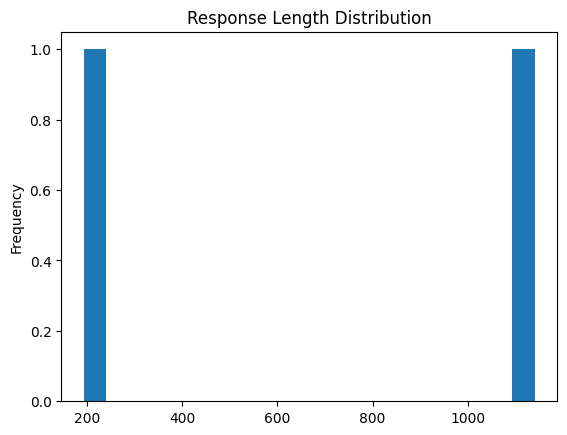

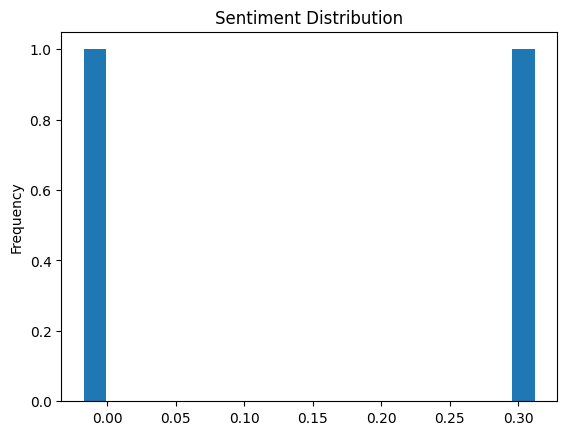

In [41]:
import matplotlib.pyplot as plt

# Response length distribution
df['response_length'].plot(kind='hist', bins=20, title="Response Length Distribution")
plt.show()

# Sentiment distribution
df['sentiment'].plot(kind='hist', bins=20, title="Sentiment Distribution")
plt.show()


In [42]:
# Save enriched dataset
df.to_csv("response_analysis.csv", index=False)

# Save word frequency
pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count']).to_csv("word_frequency.csv", index=False)
